


# Vamos encher o carrinho!

# Introdução

O Instacart é uma plataforma de entrega de supermercado onde os clientes podem fazer um pedido no supermercado e depois receber sua compra, semelhante ao funcionamento do Uber Eats e do iFood. O conjunto de dados que fornecemos foi modificado a partir do original. Reduzimos o tamanho dele para que seus cálculos sejam executados mais rapidamente e incluímos valores ausentes e duplicados. Também tivemos o cuidado de preservar as distribuições dos dados originais quando fizemos as alterações.

Você precisa completar três etapas. Para cada uma delas, escreva uma breve introdução descrevendo como você pretende concluir a etapa e justifique suas decisões em parágrafos explicativos a medida que você avança na solução. Escreva também uma conclusão para resumir suas conclusões e escolhas.



## Dicionário de dados

Há cinco tabelas no conjunto de dados, e você vai precisar usar todas elas para pré-processar seus dados e fazer AED. Abaixo está um dicionário que lista as colunas de cada tabela e descreve os dados contidos nelas.

- `instacart_orders.csv`: cada linha corresponde a um pedido no aplicativo da Instacart
    - `'order_id'`: é o número que identifica cada pedido de forma exclusiva
    - `'user_id'`: é o número de identificação exclusivo da conta de cada cliente
    - `'order_number'`: é o número de vezes que o cliente fez um pedido
    - `'order_dow'`: é o dia da semana em que o pedido foi feito (0 é domingo)
    - `'order_hour_of_day'`: é a hora do dia em que o pedido foi feito
    - `'days_since_prior_order'`: é o número de dias desde que o cliente fez seu pedido anterior




- `products.csv`: cada linha corresponde a um produto exclusivo que os clientes podem comprar
    - `'product_id'`: é o número de identificação unívoco de cada produto
    - `'product_name'`: é o nome do produto
    - `'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    - `'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado




-	`order_products.csv`: cada linha corresponde a um item incluído em um pedido
    -	`'order_id'`: é o número que identifica cada pedido de forma exclusiva
    -	`'product_id'`: é o número de identificação exclusivo de cada produto
    -	`'add_to_cart_order'`: é a ordem sequencial em que cada item foi colocado no carrinho
    -	`'reordered'`: 0 se o cliente nunca comprou o produto antes, 1 se já o comprou




-	`aisles.csv`
    -	`'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    -	`'aisle'`: é o nome do corredor



-	`departments.csv`
    -	`'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado
    -	`'department'`: é o nome do departamento


# Etapa 1. Visão geral dos dados

Leia os arquivos de dados (/datasets/instacart_orders.csv, /datasets/products.csv, /datasets/aisles.csv, /datasets/departments.csv e /datasets/order_products.csv) com `pd.read_csv()` usando os parâmetros apropriados para fazer isso corretamente. Verifique as informações para cada DataFrame criado.


## Plano de solução

Escreva aqui seu plano para a Etapa 2. Visão geral dos dados

In [13]:
# Importe as bibliotecas
import pandas as pd
import numpy as np

In [14]:
# leia os conjuntos de dados em DataFrames
instacart_orders  = pd.read_csv("/datasets/instacart_orders.csv",sep = ";")
products  = pd.read_csv("/datasets/products.csv",sep = ";")
aisles  = pd.read_csv("/datasets/aisles.csv",sep = ";")
departments  = pd.read_csv("/datasets/departments.csv",sep = ";")
order_products  = pd.read_csv("/datasets/order_products.csv",sep = ";")

In [15]:
# imprima as informações sobre o DataFrame
instacart_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB


In [16]:
# imprima as informações sobre o DataFrame
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [17]:
# imprima as informações sobre o DataFrame
aisles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [18]:
# imprima as informações sobre o DataFrame
departments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


In [19]:
# imprima as informações sobre o DataFrame
order_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB


## Conclusões

Os dados no geral foram carregados corretamente mas existem algumas ressalvas, como o formato de alguns que podem precisar de ajuste ao serem averiguados corretamente. A separação por ';' foi primordial para a boa ingestão dos dados. Alguns data frames contem dados faltantes e isso é um ponto a ser levando em conta na hora de analisar corretamente os dados. No geral, dados foram bem carregados.

# Etapa 2. Preparação de dados

Faça o pré-processamento dos dados da seguinte maneira:

-	Verifique e corrija os tipos de dados (por exemplo, certifique-se de que as colunas de ID sejam números inteiros)
-	Identifique e preencha valores ausentes
-	Identifique e remova valores duplicados

Certifique-se de explicar que tipos de valores ausentes e duplicados você encontrou, como você os preencheu ou removeu, por que escolheu esses métodos e por que você acha que esses valores ausentes e duplicados estavam presentes no conjunto de dados.

## Plano de solução

A preparação será estruturada em 3 blocos principais: tipagem, valores ausentes e duplicidades. A ideia é garantir consistência antes de qualquer análise.

## Encontre e remova valores duplicados (e descreva por que você está fazendo suas escolhas)

### DataFrame `instacart_orders`

In [20]:
instacart_orders.duplicated().sum() #quantos


15

In [21]:
instacart_orders[instacart_orders.duplicated()]# quais



,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0
284038,2845099,31189,11,3,2,7.0
311713,1021560,53767,3,3,2,9.0
321100,408114,68324,4,3,2,18.0
323900,1919531,191501,32,3,2,7.0
345917,2232988,82565,1,3,2,NaN


Há linhas duplicadas? Se sim, o que elas têm em comum?

-> Linhas duplicadas possuem todos os campos iguais.


In [22]:
orders_2am_wed = instacart_orders[
    (instacart_orders['order_dow'] == 3) &
    (instacart_orders['order_hour_of_day'] == 2)
]


print(orders_2am_wed)

orders_2am_wed.duplicated().sum()

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

15

O que esse resultado quer dizer?

-> Existe um padrão artificial de duplicação nesse recorte específico dos dados. Duplicatas foram inseridas propositalmente no dataset
ou houve erro sistemático em registros nesse horário/dia motivado por algum bug ou algo estrutural. Por fim, não é comportamento real do usuário, é problema dos dados.

In [23]:
instacart_orders = instacart_orders.drop_duplicates()
instacart_orders = instacart_orders.reset_index(drop=True)

In [24]:
instacart_orders['order_id'].duplicated().sum()

0

In [25]:
instacart_orders[instacart_orders['order_id'].duplicated(keep=False)]


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


Foram identificadas linhas completamente duplicadas no dataset instacart_orders, indicando inconsistência na base de dados, provavelmente decorrente de erros de processamento ou inserções artificiais para fins de exercício. Observou-se um padrão específico de duplicação em pedidos realizados às 2h da manhã nas quartas-feiras, o que reforça a hipótese de anomalia não relacionada ao comportamento real dos usuários.

Para garantir a integridade dos dados, as duplicatas completas foram removidas utilizando drop_duplicates(). Após a limpeza, foi feita uma nova verificação para assegurar que não restaram duplicatas, incluindo a validação da unicidade da chave order_id.

Com isso, o dataset ficou consistente e pronto para próximas análises .

### DataFrame `products`

In [26]:
products.duplicated().sum()#quantas

0

In [27]:
products['product_id'].duplicated().sum() #quantos

0

In [28]:
products[products['product_id'].duplicated(keep=False)].sort_values('product_id') #quais

,product_id,product_name,aisle_id,department_id


In [29]:


# Verifique apenas nomes de produtos duplicados (converta os nomes para minúsculas para uma comparação melhor)

products['product_name_lower'] = products['product_name'].str.lower()
products['product_name_lower'].duplicated().sum()





1361

In [30]:


# Verifique apenas nomes de produtos duplicados (converta os nomes para minúsculas para uma comparação melhor)
#visualizar
products[products['product_name_lower'].duplicated(keep=False)] \
    .sort_values('product_name_lower')





,product_id,product_name,aisle_id,department_id,product_name_lower
23339,23340,18-in-1 Hemp Peppermint Pure-Castile Soap,25,11,18-in-1 hemp peppermint pure-castile soap
31844,31845,18-In-1 Hemp Peppermint Pure-Castile Soap,25,11,18-in-1 hemp peppermint pure-castile soap
19941,19942,Aged Balsamic Vinegar Of Modena,19,13,aged balsamic vinegar of modena
13152,13153,Aged Balsamic Vinegar of Modena,19,13,aged balsamic vinegar of modena
24830,24831,Albacore Solid White Tuna in Water,95,15,albacore solid white tuna in water
...,...,...,...,...,...
49552,49553,NaN,100,21,NaN
49574,49575,NaN,100,21,NaN
49640,49641,NaN,100,21,NaN
49663,49664,NaN,100,21,NaN


In [31]:
# Verifique os nomes de produtos duplicados que não estão faltando

products_non_null = products[products['product_name'].notna()]

products_non_null[
    products_non_null['product_name_lower'].duplicated(keep=False)
].sort_values('product_name_lower')

,product_id,product_name,aisle_id,department_id,product_name_lower
23339,23340,18-in-1 Hemp Peppermint Pure-Castile Soap,25,11,18-in-1 hemp peppermint pure-castile soap
31844,31845,18-In-1 Hemp Peppermint Pure-Castile Soap,25,11,18-in-1 hemp peppermint pure-castile soap
19941,19942,Aged Balsamic Vinegar Of Modena,19,13,aged balsamic vinegar of modena
13152,13153,Aged Balsamic Vinegar of Modena,19,13,aged balsamic vinegar of modena
24830,24831,Albacore Solid White Tuna in Water,95,15,albacore solid white tuna in water
...,...,...,...,...,...
46873,46874,Vitamin D3 5000 IU,47,11,vitamin d3 5000 iu
21366,21367,Wild Sardines in Spring Water,95,15,wild sardines in spring water
40093,40094,Wild Sardines In Spring Water,95,15,wild sardines in spring water
1826,1827,Yams Cut Sweet Potatoes in Syrup,81,15,yams cut sweet potatoes in syrup


É perceptível que os produtos duplicados possuem apenas um ID que os diferencia, evidenciando que foram cadastrados duas vezes ou mais em momentos diferentes, ou algo parecido. No fim, apenas um descuido com a base de dados e a averiguação dos produtos.

### DataFrame `departments`

In [32]:
departments.duplicated().sum()

0

In [33]:
departments[departments.duplicated()]

,department_id,department


In [34]:
departments['department_id'].duplicated().sum()

0

In [35]:
departments[departments['department_id'].duplicated(keep=False)] \
    .sort_values('department_id').head(5)

,department_id,department


A base de dados do Departamento aparenta não ter dados duplicados o que evidencia um bom carregamento dos dados.

### DataFrame `aisles`

In [36]:
# Verifique se há linhas completamente duplicadas
aisles.duplicated().sum()

0

In [37]:
# Verifique apenas IDs duplicados de corredores
aisles['aisle_id'].duplicated().sum()

0

A base de dados 'Aisles' aparenta não ter dados duplicados o que evidencia um bom carregamento dos dados.

### DataFrame `order_products`

In [38]:
# Verifique se há linhas completamente duplicadas
order_products.duplicated().sum()


0

In [39]:
# Verifique se há linhas completamente duplicadas
print(order_products.columns)


Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered'], dtype='object')


In [40]:
# Verifique mais uma vez se há outros casos complicados de duplicados
order_products.duplicated(
    subset=['order_id', 'product_id', 'add_to_cart_order', 'reordered']
).sum()

0

In [41]:
# O mesmo pedido (teste)
order_products.duplicated(subset=['order_id']).sum()


4094961

In [42]:
# O Mesmo produto no mesmo pedido (teste)
order_products.duplicated(subset=['order_id', 'product_id']).sum()


0

A base de dados 'order_products' aparenta não ter dados duplicados, de maneira geral, o que evidencia um bom carregamento dos dados. Com exceção da coluna 'order_id', que mostra que mais de um produto foi adquirido no mesmo pedido em alguns bons pedidos.


### DataFrame `products`

## Encontre e remova valores ausentes


Ao processarmos valores duplicados, observamos que também temos valores ausentes que precisamos investigar nas seguintes colunas:

*	A coluna `'product_name'` da tabela products.
*	A coluna `'days_since_prior_order'` da tabela orders.
*	A coluna `'add_to_cart_order'` da tabela order_products.

In [43]:
products['product_name'].isna().sum()

1258

Existe uma quantidade considerável de valores ausentes na base de dados de produto.

In [44]:
products[products['product_name'].isna()]

,product_id,product_name,aisle_id,department_id,product_name_lower
37,38,NaN,100,21,NaN
71,72,NaN,100,21,NaN
109,110,NaN,100,21,NaN
296,297,NaN,100,21,NaN
416,417,NaN,100,21,NaN
...,...,...,...,...,...
49552,49553,NaN,100,21,NaN
49574,49575,NaN,100,21,NaN
49640,49641,NaN,100,21,NaN
49663,49664,NaN,100,21,NaN


Tudo indica que os dados faltantes não são aleatórios e estão associados a uma ala e um departamento em específico.

In [45]:
# Todos os nomes de produtos ausentes estão associados com o departamento de ID 21?
products[products['product_name'].isna()]['department_id'].unique()

array([21])

In [46]:
(products[products['product_name'].isna()]['department_id'] == 21).all()


True

In [47]:
departments[departments['department_id'] == 21].head(5)

,department_id,department
20,21,missing


A análise mostrou que os valores ausentes em product_name não são aleatórios e de fato estão associados ao departamento 21, unicamente.

In [48]:
products[products['product_name'].isna()]['aisle_id'].unique()

array([100])

In [49]:
(products[products['product_name'].isna()]['aisle_id'] == 100).all()

True

In [50]:
aisles[aisles['aisle_id'] == 100]

,aisle_id,aisle
99,100,missing


A análise mostrou que os valores ausentes em product_name não são aleatórios e de fato estão associados a ala 100, unicamente.

In [51]:
products['product_name'] = products['product_name'].fillna('Unknown')

Para que a base não contenha dados nulos, foram incrementados aos nulos a informação de "Desconhecido" para a ala 100 e o departamento 21 específicamente.

### DataFrame `orders`

In [52]:
instacart_orders.isna().sum()

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

In [53]:
instacart_orders['days_since_prior_order'].isna().sum()

28817

In [54]:
# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?
instacart_orders[
    (instacart_orders['days_since_prior_order'].isna()) &
    (instacart_orders['order_number'] > 1)
].head(5)

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order


In [55]:
instacart_orders[
    (instacart_orders['days_since_prior_order'].isna()) &
    (instacart_orders['order_number'] > 1)
].shape[0]

0

Os valores ausentes na coluna 'days_since_prior_order' acontecem naturalmente pelo fato de não haver nenhum pedido que antecede o primeiro pedido (order_number = 1).

### DataFrame `order_products`

In [56]:
order_products.isna().sum()

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [57]:
order_products['add_to_cart_order'].isna().sum()

836

In [58]:
order_products[order_products['add_to_cart_order'].isna()]

,order_id,product_id,add_to_cart_order,reordered
737,2449164,5068,NaN,0
9926,1968313,43867,NaN,0
14394,2926893,11688,NaN,0
16418,1717990,4142,NaN,0
30114,1959075,42828,NaN,1
...,...,...,...,...
4505662,1800005,7411,NaN,0
4511400,1633337,260,NaN,0
4517562,404157,9517,NaN,0
4534112,1673227,17835,NaN,0


In [59]:
order_products['add_to_cart_order'].min()

1.0

In [60]:
order_products['add_to_cart_order'].max()

64.0

A coluna add_to_cart_order apresenta valores ausentes que indicam falta de informação sobre a sequência de adição de produtos ao carrinho. Diferente de outros casos, esses valores não têm uma interpretação direta (como no caso de primeiro pedido), o que sugere inconsistência ou perda de dados.

No order_products, dá pra ver que existem valores ausentes na coluna add_to_cart_order, que representa a ordem em que o item foi adicionado ao carrinho. Diferente de outros casos, esses NaN não têm uma explicação clara, então provavelmente vêm de algum problema no dado. Os valores válidos começam em 1, o que faz sentido, e o máximo varia conforme o tamanho do pedido. Isso mostra que a coluna é sequencial por pedido. No fim, dá pra manter esses NaN ou remover, dependendo se a análise precisa da ordem dos itens ou não.


In [61]:
orders_with_nan = order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()
orders_with_nan.shape[0]#contagem

70

In [62]:
# Todos os pedidos com valores ausentes contêm mais de 64 produtos?
orders_counts = order_products[
    order_products['order_id'].isin(orders_with_nan)
].groupby('order_id')['product_id'].count()

if (orders_counts > 64).all():
    print("Todos os pedidos com valores ausentes têm mais de 64 produtos.")
else:
    print("Nem todos os pedidos com valores ausentes têm mais de 64 produtos.")



Todos os pedidos com valores ausentes têm mais de 64 produtos.


In [63]:
# Agrupe os pedidos com dados ausentes por ID de pedido
orders_counts = order_products[
    order_products['order_id'].isin(orders_with_nan)
].groupby('order_id')['product_id']
print(orders_counts.head(5))

267       31469
737        5068
1742       4920
3463      40063
3535      36397
          ...  
607447    38200
650703    47766
722943    47335
838640     7631
840691    22128
Name: product_id, Length: 350, dtype: int64


In [64]:
# Conte o número de 'product_id' em cada pedido e verifique o valor mínimo da contagem
orders_counts = order_products[
    order_products['order_id'].isin(orders_with_nan)
].groupby('order_id')['product_id'].count()
print(orders_counts)
print()
print("O mínimo de produtos num pedido é:",orders_counts.min())

order_id
9310        65
61355      127
102236      95
129627      69
165801      70
          ... 
2999801     70
3125735     86
3308010    115
3347453     71
3383594     69
Name: product_id, Length: 70, dtype: int64

O mínimo de produtos num pedido é: 65


Olhando esses pedidos com add_to_cart_order ausente, dá pra ver que eles seguem um padrão bem específico. Todos eles têm uma quantidade alta de produtos, e quando agrupa-se por pedido, o mínimo já é acima de 64 itens. Isso indica que não é um erro aleatório, mas sim algo relacionado a pedidos muito grandes. Provavelmente, a informação da ordem dos itens se perde quando o volume passa de certo limite. Então faz sentido tratar isso como uma limitação do dado, não exatamente um erro isolado.

In [65]:
# Substitua valores ausentes na coluna 'add_to_cart_order' por 999 e converta a coluna para o tipo integer
order_products['add_to_cart_order'] = order_products['add_to_cart_order'] \
    .fillna(999) \
    .astype(int)

Os valores ausentes em 'add_to_cart_order' seguem um padrão específico e estão associados a pedidos com grande quantidade de itens, indicando uma limitação do dataset e não um erro aleatório. Para manter a consistência da coluna e evitar perda de dados, substituí os valores ausentes por 999, sinalizando uma posição fora da sequência normal. Em seguida, converti a coluna para inteiro para garantir compatibilidade com análises futuras. Dessa forma, os dados foram padronizados sem excluir registros relevantes.

## Conclusões

Na etapa de preparação dos dados, foi possível identificar e corrigir problemas estruturais importantes que poderiam comprometer a análise. Primeiro, os tipos de dados foram ajustados para garantir consistência, principalmente nas colunas de ID e variáveis numéricas. Em relação aos valores ausentes, foi observado que alguns tinham significado lógico (como no caso de days_since_prior_order, relacionado ao primeiro pedido), enquanto outros, como product_name e add_to_cart_order, foram tratados com substituições adequadas ('Unknown' e 999, respectivamente) para evitar perda de informação.

Também foram identificadas duplicidades em algumas tabelas, especialmente em instacart_orders e order_products. As duplicatas completas foram removidas, e casos mais complexos foram analisados com cuidado para não eliminar dados válidos. No geral, o tratamento foi feito de forma criteriosa, considerando o contexto de cada variável, garantindo que o dataset final ficasse consistente, íntegro e pronto para a análise exploratória.

# Etapa 3. Análise de dados

Quando os dados estiverem processados ​​e prontos, execute a seguinte análise:

# [A] Fácil (é necessário concluir tudo para passar)

1.	Verifique se os valores nas colunas `'order_hour_of_day'` e `'order_dow'` na tabela `orders` fazem sentido (ou seja, os valores da coluna  `'order_hour_of_day'` variam de 0 a 23 e os da `'order_dow'` variam de 0 a 6).
2.	Crie um gráfico que mostre quantas pessoas fazem pedidos a cada hora do dia.
3.	Crie um gráfico que mostre em que dia da semana as pessoas fazem compras.
4.	Crie um gráfico que mostre quanto tempo as pessoas esperam até fazer seu próximo pedido e comente sobre os valores mínimo e máximo.

### [A1] Verifique os valores

In [66]:
# Verificar intervalos
instacart_orders['order_hour_of_day'].min(), instacart_orders['order_hour_of_day'].max()

(0, 23)

In [67]:
# Verificar intervalos
instacart_orders['order_dow'].min(), instacart_orders['order_dow'].max()

(0, 6)

In [68]:
# Validação => se estiverem vazios está correto
invalid_hours = instacart_orders[
    ~instacart_orders['order_hour_of_day'].between(0, 23)
]

In [69]:
# Validação => se estiverem vazios está correto
invalid_dow = instacart_orders[
    ~instacart_orders['order_dow'].between(0, 6)
]

Os valores parecem estar consistentes.

### [A2] Quantas pessoas fazem pedidos a cada hora do dia?

In [70]:

orders_by_hour = instacart_orders['order_hour_of_day'].value_counts().sort_index()
orders_by_hour.head(24)


0      3180
1      1763
2       989
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: order_hour_of_day, dtype: int64

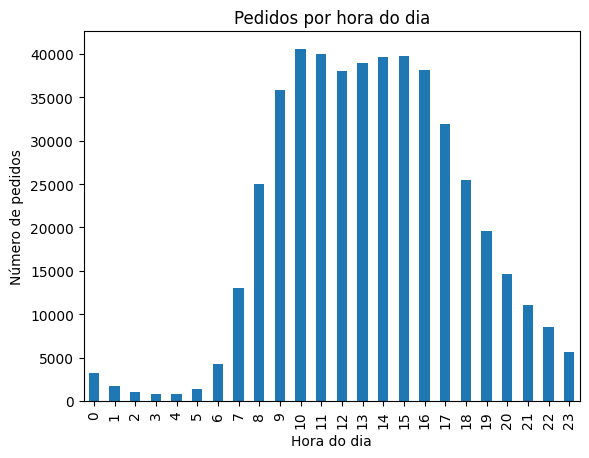

In [71]:
import matplotlib.pyplot as plt

orders_by_hour = instacart_orders['order_hour_of_day'].value_counts().sort_index()

orders_by_hour.plot(kind='bar')
plt.xlabel('Hora do dia')
plt.ylabel('Número de pedidos')
plt.title('Pedidos por hora do dia')
plt.show()

Os pedido acontecem em sua maioria entre 8 e e 18, que é o horário comercial. Foram deste período os resultados decaem consideravelmente, tendo uma baixa considerável no intervalo das 23 horas as 6 horas da manhã, quando a maioria das pessoas estão dormindo.

### [A3] Em que dia da semana as pessoas compram produtos alimentícios?

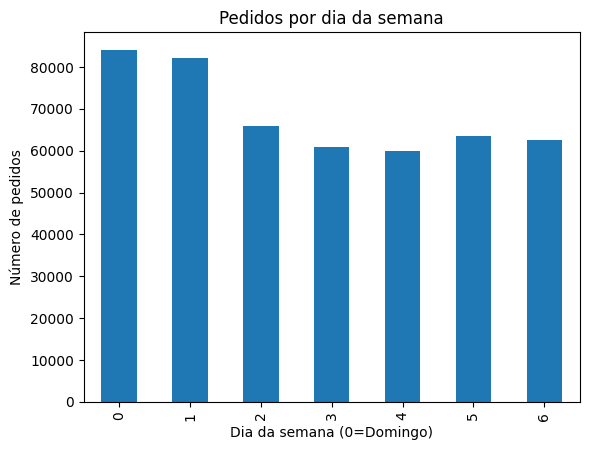

In [72]:
orders_by_dow = instacart_orders['order_dow'].value_counts().sort_index()

orders_by_dow.plot(kind='bar')
plt.xlabel('Dia da semana (0=Domingo)')
plt.ylabel('Número de pedidos')
plt.title('Pedidos por dia da semana')
plt.show()

Num primeiro momento, domingo e segunda-feira, os dois primeiros dias da semana, se destacam dos demais quanto ao volume de pedidos, sendo a quinta-feira o pior dia da semana nesta avaliação do volume de pedidos.

### [A4] Quanto tempo as pessoas esperam até fazer outro pedido?

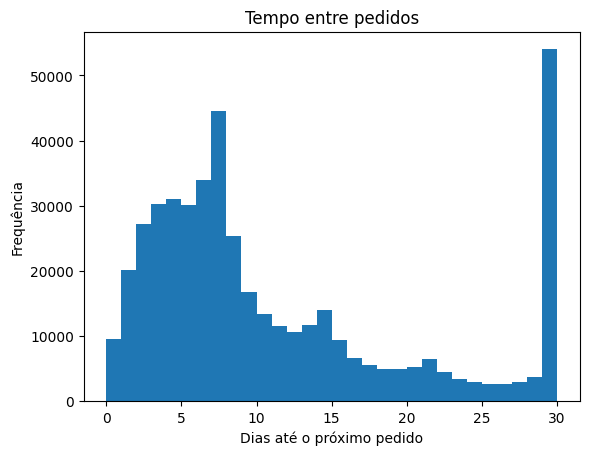

In [73]:
days_wait = instacart_orders['days_since_prior_order']

days_wait.plot(kind='hist', bins=30)
plt.xlabel('Dias até o próximo pedido')
plt.ylabel('Frequência')
plt.title('Tempo entre pedidos')
plt.show()

De acordo com o gráfico, uma boa das pessoas se organiza para reporem os produtos semanalmente, uma parcela menor quizenalmente pelos valores de salto do gráfico, sempre com picos de 7 em 7 dias. Contudo existe uma marca muito clara que uma grande parte se organiza com compras mensais, de 30 em 30 dias.

# [B] Médio (é necessário concluir tudo para passar)
1.	Há alguma diferença nas distribuições de `'order_hour_of_day'` nas quartas e sábados? Construa gráficos de barras para ambos os dias no mesmo gráfico e descreva as diferenças que você notou.
2.	Construa um gráfico de distribuição para o número de pedidos que os clientes fazem (ou seja, quantos clientes fizeram apenas 1 pedido, quantos fizeram apenas 2, quantos apenas 3, etc.)
3.	Quais são os 20 produtos comprados com mais frequência? Exiba os IDs e nomes.

### [B1] Diferenças nas quartas e sábados em `'order_hour_of_day'`. Crie gráficos de barras para ambos os dias e descreva as diferenças.

In [74]:
import matplotlib.pyplot as plt

# Filtrar dias
quarta = instacart_orders[instacart_orders['order_dow'] == 3]
sab = instacart_orders[instacart_orders['order_dow'] == 6]

# Contagem por hora
quarta_counts = quarta['order_hour_of_day'].value_counts().sort_index()
sab_counts = sab['order_hour_of_day'].value_counts().sort_index()
print("quarta")
print(quarta_counts.head(10))
print("_______________________________________")
print()
print("sabado")
print(sab_counts.head(10))

quarta
0     373
1     215
2     106
3     101
4     108
5     170
6     643
7    1732
8    3125
9    4490
Name: order_hour_of_day, dtype: int64
_______________________________________

sabado
0     464
1     254
2     177
3     125
4     118
5     161
6     451
7    1619
8    3246
9    4311
Name: order_hour_of_day, dtype: int64


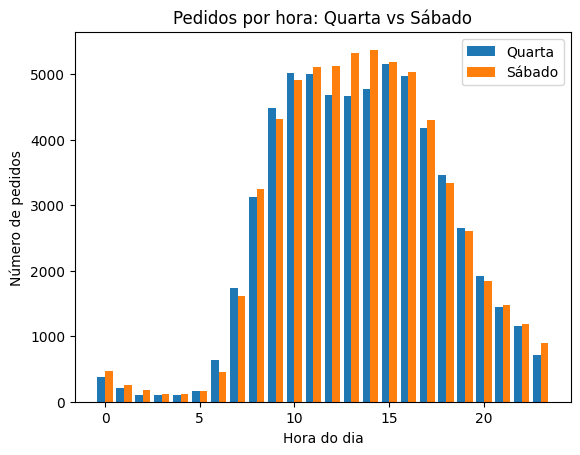

In [75]:
# Mesmo indice
horas = range(24)
quarta_counts = quarta_counts.reindex(horas, fill_value=0)
sab_counts = sab_counts.reindex(horas, fill_value=0)

# Plot lado a lado (sem sobrepor)
x = range(24)
width = 0.4

plt.figure()
plt.bar([h - width/2 for h in x], quarta_counts, width=width, label='Quarta')
plt.bar([h + width/2 for h in x], sab_counts, width=width, label='Sábado')

plt.xlabel('Hora do dia')
plt.ylabel('Número de pedidos')
plt.title('Pedidos por hora: Quarta vs Sábado')
plt.legend()
plt.show()

Comparando quarta e sábado, dá pra ver que o padrão geral de horários é parecido, com maior volume durante o dia. A principal diferença costuma ser que no sábado o volume total é maior e um pouco mais distribuído ao longo do dia, enquanto na quarta tende a ser mais concentrado em horários específicos.

### [B2] Qual é a distribuição do número de pedidos por cliente?

In [76]:
orders_cliente = instacart_orders.groupby('user_id')['order_id'].count()
orders_dist = orders_cliente.value_counts().sort_index()
print("contagem de pedidos p cliente")
orders_dist.head(10)

contagem de pedidos p cliente


1     55357
2     36508
3     21547
4     13498
5      8777
6      6012
7      4240
8      3019
9      2152
10     1645
Name: order_id, dtype: int64

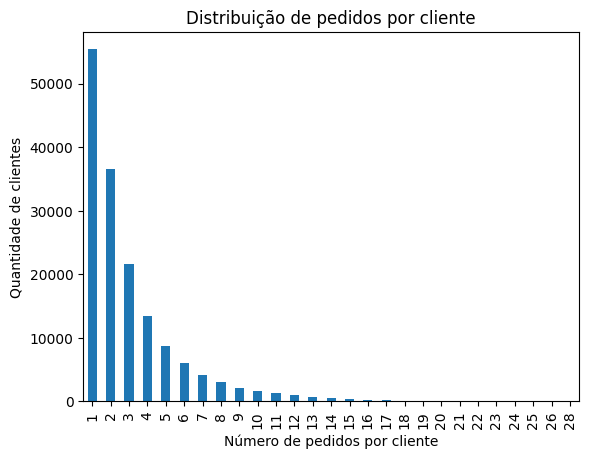

In [77]:
#gráfico
plt.figure()
orders_dist.plot(kind='bar')

plt.xlabel('Número de pedidos por cliente')
plt.ylabel('Quantidade de clientes')
plt.title('Distribuição de pedidos por cliente')
plt.show()

Aqui normalmente aparece uma distribuição concentrada em poucos pedidos, com muitos usuários fazendo poucos pedidos e poucos usuários fazendo muitos pedidos. Ou seja, comportamento típico de cauda longa.

### [B3] Quais são os 20 produtos mais populares? Exiba os IDs e nomes.

In [78]:
top_produtos = order_products['product_id'].value_counts().head(20)
print(top_produtos)

24852    66050
13176    53297
21137    37039
21903    33971
47209    29773
47766    24689
47626    21495
16797    20018
26209    19690
27845    19600
27966    19197
22935    15898
24964    15292
45007    14584
39275    13879
49683    13675
28204    12544
5876     12232
8277     11993
40706    11781
Name: product_id, dtype: int64


In [79]:
top_produtos = top_produtos.reset_index()
top_produtos.columns = ['product_id', 'count']

# Juntar com tabela de produtos
top_produtos = top_produtos.merge(products, on='product_id')

top_produtos[['product_id', 'product_name']]

,product_id,product_name
0,24852,Banana
1,13176,Bag of Organic Bananas
2,21137,Organic Strawberries
3,21903,Organic Baby Spinach
4,47209,Organic Hass Avocado
5,47766,Organic Avocado
6,47626,Large Lemon
7,16797,Strawberries
8,26209,Limes
9,27845,Organic Whole Milk


Os produtos mais comprados tendem a ser itens básicos do dia a dia (como frutas e legumes, etc.), o que mostra que o uso do app está muito ligado a reposição frequente e compras recorrentes, não tanto a compras ocasionais.

# [C] Difícil (é necessário concluir pelo menos duas perguntas para passar)

1.	Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?
2.	Quais são os 20 principais itens incluídos mais frequentemente em pedidos repetidos? Exiba os IDs e nomes.
3.	Para cada produto, qual parcela de seus pedidos são repetidos? Crie uma tabela com colunas de ID e nome do produto e a proporção de pedidos repetidos.
4.	Para cada cliente, qual proporção de todos os seus pedidos são repetidos?
5.	Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros? Exiba o ID do produto, nome e o número de vezes que ele foi o primeiro a ser adicionado a um carrinho.


### [C1] Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?

In [80]:
items_p_pedido = order_products.groupby('order_id')['product_id'].count()
print(items_p_pedido)

order_id
4          13
9          15
11          5
19          3
20          8
           ..
3421034    17
3421053     9
3421071     5
3421077     4
3421079     1
Name: product_id, Length: 450046, dtype: int64


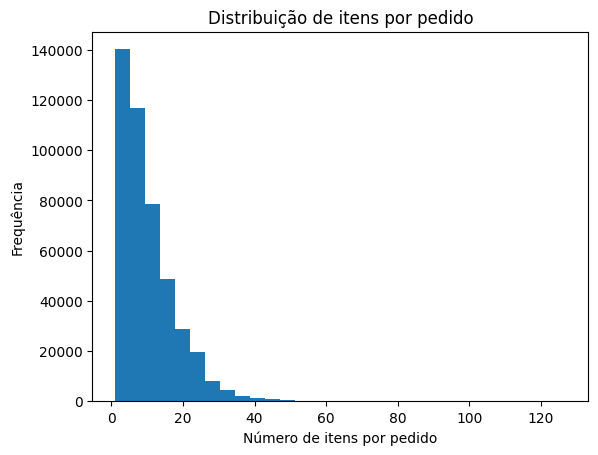

count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
Name: product_id, dtype: float64

In [81]:
plt.figure()
items_p_pedido.plot(kind='hist', bins=30)

plt.xlabel('Número de itens por pedido')
plt.ylabel('Frequência')
plt.title('Distribuição de itens por pedido')
plt.show()

items_p_pedido.describe()

A maioria dos pedidos costuma ter poucos itens, com alguns pedidos grandes puxando a cauda da distribuição.

### [C2] Quais são os 20 principais itens incluídos com mais frequência em pedidos repetidos? Exiba os IDs e nomes.

In [82]:
reordered = order_products[order_products['reordered'] == 1]

top_reordered = reordered['product_id'].value_counts().head(20).reset_index()
top_reordered.columns = ['product_id', 'count']

top_reordered = top_reordered.merge(products, on='product_id')

top_reordered[['product_id', 'product_name']]

,product_id,product_name
0,24852,Banana
1,13176,Bag of Organic Bananas
2,21137,Organic Strawberries
3,21903,Organic Baby Spinach
4,47209,Organic Hass Avocado
5,47766,Organic Avocado
6,27845,Organic Whole Milk
7,47626,Large Lemon
8,27966,Organic Raspberries
9,16797,Strawberries


Mostra os produtos com maior recorrência e aparentemente são itens de consumo frequente no geral, de acordo com a abordagem dos top 20 produtos mais vendidos.

### [C3] Para cada produto, qual parcela de todos os pedidos dele são repetidos?

In [83]:
product_reorder_ratio = order_products.groupby('product_id')['reordered'].mean().reset_index()

product_reorder_ratio = product_reorder_ratio.merge(products, on='product_id')

product_reorder_ratio = product_reorder_ratio.sort_values(by='reordered', ascending=False)
product_reorder_ratio[['product_id', 'product_name', 'reordered']].head(20)

,product_id,product_name,reordered
13453,14721,Bone Strength Take Care,1.0
19195,20949,Vanilla Sandwich Cookies,1.0
6136,6723,Palmiers- Petite,1.0
6144,6732,Naturally Sparkling Mineral Water,1.0
41319,45088,California Dill Pollen & Garlic Goat Cheese & ...,1.0
41310,45078,Pomegranatea,1.0
19258,21016,Parchment Lined 8 in x 3.75 in x 2.5 in Pans,1.0
19248,21005,Peanut Butter Pie Ice Cream,1.0
32273,35192,Chocolate Soy Milk Singles,1.0
32277,35197,Mocha Chocolate Chip Organic Non-Dairy Frozen...,1.0


Esses produtos representam prioridade de compra pelo cliente, desde produtos complexos até mesmo itens essenciais ou mais lembrados pelo usuário.

### [C4] Para cada cliente, qual proporção de todos os seus pedidos são repetidos?

In [84]:
user_orders = order_products.merge(instacart_orders[['order_id', 'user_id']], on='order_id')

user_reorder_ratio = user_orders.groupby('user_id')['reordered'].mean().reset_index()
user_reorder_ratio = user_reorder_ratio.sort_values(by='reordered', ascending=False)
user_reorder_ratio.head(20)

,user_id,reordered
99672,137587,1.0
125732,173474,1.0
10138,13918,1.0
45067,62300,1.0
45074,62307,1.0
69811,96301,1.0
45076,62312,1.0
35222,48616,1.0
45079,62316,1.0
138633,191162,1.0


Essa análise mostra o quanto cada cliente tende a recomprar os mesmos itens e nesse caso, temos vários clientes que compram sempre a mesma coisa.

### [C5] Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros?

In [85]:
first_added = order_products[order_products['add_to_cart_order'] == 1]

top_first = first_added['product_id'].value_counts().head(20).reset_index()
top_first.columns = ['product_id', 'count']

top_first = top_first.merge(products, on='product_id')

top_first[['product_id', 'product_name', 'count']]

,product_id,product_name,count
0,24852,Banana,15562
1,13176,Bag of Organic Bananas,11026
2,27845,Organic Whole Milk,4363
3,21137,Organic Strawberries,3946
4,47209,Organic Hass Avocado,3390
5,21903,Organic Baby Spinach,3336
6,47766,Organic Avocado,3044
7,19660,Spring Water,2336
8,16797,Strawberries,2308
9,27966,Organic Raspberries,2024


Temos aqui alguns produtos que são totalmente a prioridade de compra, tanto que se distanciam dos demais, sendo bananas, tanto orgânica quanto a Banana normal. Depois temos leite orgânico, seguido tanto de morangos quanto abacates orgânicos. No geral, items da alimentação do dia a dia e com o detalhe: orgânicos, mostrando uma tendência da população em geral no consumo destes itens.

# Conclusão geral do projeto:


No geral, esse projeto mostrou bem como dados “aparentemente prontos” ainda podem ter vários problemas que impactam diretamente a análise. Logo no início já deu pra ver erro de leitura dos arquivos, além de duplicidades e valores ausentes que precisaram ser tratados com cuidado, sempre considerando o contexto de cada coluna. Em alguns casos, como days_since_prior_order, os NaN faziam sentido; em outros, como add_to_cart_order, ficou claro que era uma limitação do dataset.

Depois da limpeza, a análise exploratória trouxe alguns padrões bem claros: pedidos concentrados durante o dia, comportamento consistente ao longo da semana e uma forte recorrência na compra de certos produtos. Também ficou evidente que muitos usuários fazem compras frequentes com poucos itens, enquanto poucos usuários concentram pedidos maiores.

No fim, o principal aprendizado aqui foi mais sobre a importância do pré-processamento do que sobre os gráficos em si. Garantir a qualidade dos dados foi essencial pra conseguir extrair qualquer insight confiável depois.